##Kaggle Data

In [ ]:
!pip install kaggle

In [ ]:
!pip install opendatasets

In [ ]:
# Running this code cell will require you to log in to Kaggle
"""
You can enter your  Kaggle Username
For Kaggle Key, you can enter the password, or generate an API key via settings
"""
import opendatasets as od

od.download("https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: cura@uni.minerva.edu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023


100%|██████████| 464M/464M [00:04<00:00, 122MB/s] 


In [ ]:
#Show all the files from the Kaggle dataset
!ls "time-series-air-quality-data-of-india-2010-2023"

AP001.csv  DL005.csv  HR023.csv  MH018.csv  RJ004.csv	       UK001.csv
AP002.csv  DL006.csv  HR024.csv  MH019.csv  RJ005.csv	       UK002.csv
AP003.csv  DL007.csv  HR025.csv  MH020.csv  RJ006.csv	       UK003.csv
AP004.csv  DL008.csv  HR026.csv  MH021.csv  RJ007.csv	       UP001.csv
AP005.csv  DL009.csv  HR027.csv  MH022.csv  RJ008.csv	       UP002.csv
AP006.csv  DL010.csv  HR028.csv  MH023.csv  RJ009.csv	       UP003.csv
AP007.csv  DL011.csv  HR029.csv  MH024.csv  RJ010.csv	       UP004.csv
AP008.csv  DL012.csv  HR030.csv  MH025.csv  RJ011.csv	       UP005.csv
AP009.csv  DL013.csv  JH001.csv  MH026.csv  RJ012.csv	       UP006.csv
AP010.csv  DL014.csv  JH002.csv  MH027.csv  RJ013.csv	       UP007.csv
AR001.csv  DL015.csv  JK001.csv  MH028.csv  RJ014.csv	       UP008.csv
AS001.csv  DL016.csv  KA001.csv  MH029.csv  RJ015.csv	       UP009.csv
AS002.csv  DL017.csv  KA002.csv  MH030.csv  RJ016.csv	       UP010.csv
AS003.csv  DL018.csv  KA003.csv  MH031.csv  RJ017.csv	       UP011.csv
AS004.

We started out this data exploration by using the source file to identify the location of the Hyderabad data.

From Kaggle documentation, "stations_info.csv" is the file where in we can find and filter relevant information about a city.

Let's use stations_info.csv to filter (from the many files) all the files that are associated with Hyderabad.

In [ ]:
import pandas as pd

guide_df = pd.read_csv("/content/time-series-air-quality-data-of-india-2010-2023/stations_info.csv")

# Quick check of columns
guide_df.head()


,file_name,state,city,agency,station_location,start_month,start_month_num,start_year
0,AP001,Andhra Pradesh,Tirupati,APPCB,"Tirumala, Tirupati",July,7,2016
1,AP002,Andhra Pradesh,Vijayawada,APPCB,"PWD Grounds, Vijayawada",May,5,2017
2,AP003,Andhra Pradesh,Visakhapatnam,APPCB,"GVM Corporation, Visakhapatnam",July,7,2017
3,AP004,Andhra Pradesh,Rajamahendravaram,APPCB,"Anand Kala Kshetram, Rajamahendravaram",September,9,2017
4,AP005,Andhra Pradesh,Amaravati,APPCB,"Secretariat, Amaravati",November,11,2017


In [ ]:
hyderabad_files = guide_df[guide_df["city"].str.lower() == "hyderabad"]

# List the file names
print(hyderabad_files["file_name"].tolist())

['TG001', 'TG002', 'TG003', 'TG004', 'TG005', 'TG006', 'TG007', 'TG008', 'TG009', 'TG010', 'TG011', 'TG012', 'TG013', 'TG014']


Although we expected to receive one file name for Hyderabad data, we received 14. This is because Hyderabad had 14 measurement stations across the city. As we could use any one of these files, this created the need to explore and compare these 14 datasets to find the one that contained the most useful or complete data for our needs.

### Comparing different Hyderabad files:
Since we have 14 files for Hyderabad, the code cells below are going to investigate how each file differs in the date range, number of variables measured, and missingness across the variables.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
import os

# Folder containing all Hyderabad CSVs
folder = "/content/time-series-air-quality-data-of-india-2010-2023"

# List of Hyderabad CSV files
hyderabad_files = [
    'TG001.csv', 'TG002.csv', 'TG003.csv', 'TG004.csv', 'TG005.csv', 'TG006.csv',
    'TG007.csv', 'TG008.csv', 'TG009.csv', 'TG010.csv', 'TG011.csv', 'TG012.csv',
    'TG013.csv', 'TG014.csv'
]

In [ ]:
date_ranges = []

for fname in hyderabad_files:
    file_path = os.path.join(folder, fname)
    df = pd.read_csv(file_path)

    # Use 'Date' column if exists, else fallback to first column
    date_col = "Date" if "Date" in df.columns else df.columns[0]

    # Ensure datetime format
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    min_date = df[date_col].min()
    max_date = df[date_col].max()
    range_days = (max_date - min_date).days + 1

    num_columns = len(df.columns)

    date_ranges.append([fname, min_date, max_date, range_days, num_columns])

# Print nicely
print(tabulate(date_ranges, headers=["Filename", "Contains dates from", "To", "Range (in days)", "# of variables measured"], tablefmt="grid"))

+------------+-----------------------+---------------------+-------------------+---------------------------+
| Filename   | Contains dates from   | To                  |   Range (in days) |   # of variables measured |
+============+=======================+=====================+===================+===========================+
| TG001.csv  | 2010-12-01 00:00:00   | 2023-03-31 23:00:00 |              4504 |                        20 |
+------------+-----------------------+---------------------+-------------------+---------------------------+
| TG002.csv  | 2015-10-01 09:00:00   | 2021-06-14 07:00:00 |              2083 |                        23 |
+------------+-----------------------+---------------------+-------------------+---------------------------+
| TG003.csv  | 2016-09-01 11:00:00   | 2023-03-31 23:00:00 |              2403 |                        23 |
+------------+-----------------------+---------------------+-------------------+---------------------------+
| TG004.csv  | 2017

In [ ]:
folder = "/content/time-series-air-quality-data-of-india-2010-2023"

hyderabad_files = [
    'TG001.csv', 'TG002.csv', 'TG003.csv', 'TG004.csv', 'TG005.csv', 'TG006.csv',
    'TG007.csv', 'TG008.csv', 'TG009.csv', 'TG010.csv', 'TG011.csv', 'TG012.csv',
    'TG013.csv', 'TG014.csv'
]

# First, find the union of all columns across all files
all_columns = set()
for fname in hyderabad_files:
    df = pd.read_csv(os.path.join(folder, fname))
    all_columns.update(df.columns)

all_columns = sorted(all_columns)  # optional: sort alphabetically

# Initialize empty DataFrame with columns = all_columns, index = files
missingness_df = pd.DataFrame(index=hyderabad_files, columns=all_columns)

# Fill in % missingness per file
for fname in hyderabad_files:
    df = pd.read_csv(os.path.join(folder, fname))
    pct_missing = df.isnull().mean() * 100

    # This will automatically align by column names
    missingness_df.loc[fname, pct_missing.index] = pct_missing

# missing columns in a file remain NaN (will show as blank in heatmap)
missingness_df = missingness_df.astype(float)  # ensure numeric for heatmap

# Quick look
missingness_df.head()

,AT (degree C),BP (mmHg),Benzene (ug/m3),CO (mg/m3),Eth-Benzene (ug/m3),From Date,MP-Xylene (ug/m3),NH3 (ug/m3),NO (ug/m3),NO2 (ug/m3),...,SO2 (ug/m3),SR (W/mt2),Temp (degree C),To Date,Toluene (ug/m3),VWS (m/s),WD (deg),WD (degree),WS (m/s),Xylene (ug/m3)
TG001.csv,51.773424,21.726983,27.369190,19.898054,NaN,0.0,NaN,NaN,20.148757,20.345804,...,21.288484,20.318051,59.653456,0.0,28.138877,20.318976,20.767651,NaN,20.405935,27.915001
TG002.csv,15.982877,16.076894,14.518613,12.046168,NaN,0.0,NaN,13.364406,13.014343,14.036527,...,14.354584,15.990878,16.336941,0.0,14.572623,15.586806,15.902863,NaN,15.740833,14.512612
TG003.csv,10.629368,13.192626,7.566639,6.463641,NaN,0.0,NaN,18.046860,10.584277,11.019580,...,14.600857,9.104941,10.657117,0.0,7.585717,9.070255,14.699710,NaN,10.807998,7.570108
TG004.csv,6.341884,6.619412,5.717447,6.383138,NaN,0.0,NaN,15.556556,6.454395,6.484398,...,7.009451,5.648065,6.199370,0.0,5.717447,91.527903,7.091959,NaN,7.712646,5.713696
TG005.csv,2.906541,2.925293,1.706421,1.563906,NaN,0.0,NaN,11.123612,2.953420,4.762976,...,5.070507,1.717672,2.812781,0.0,1.796430,1.717672,3.838509,NaN,2.840909,1.640789


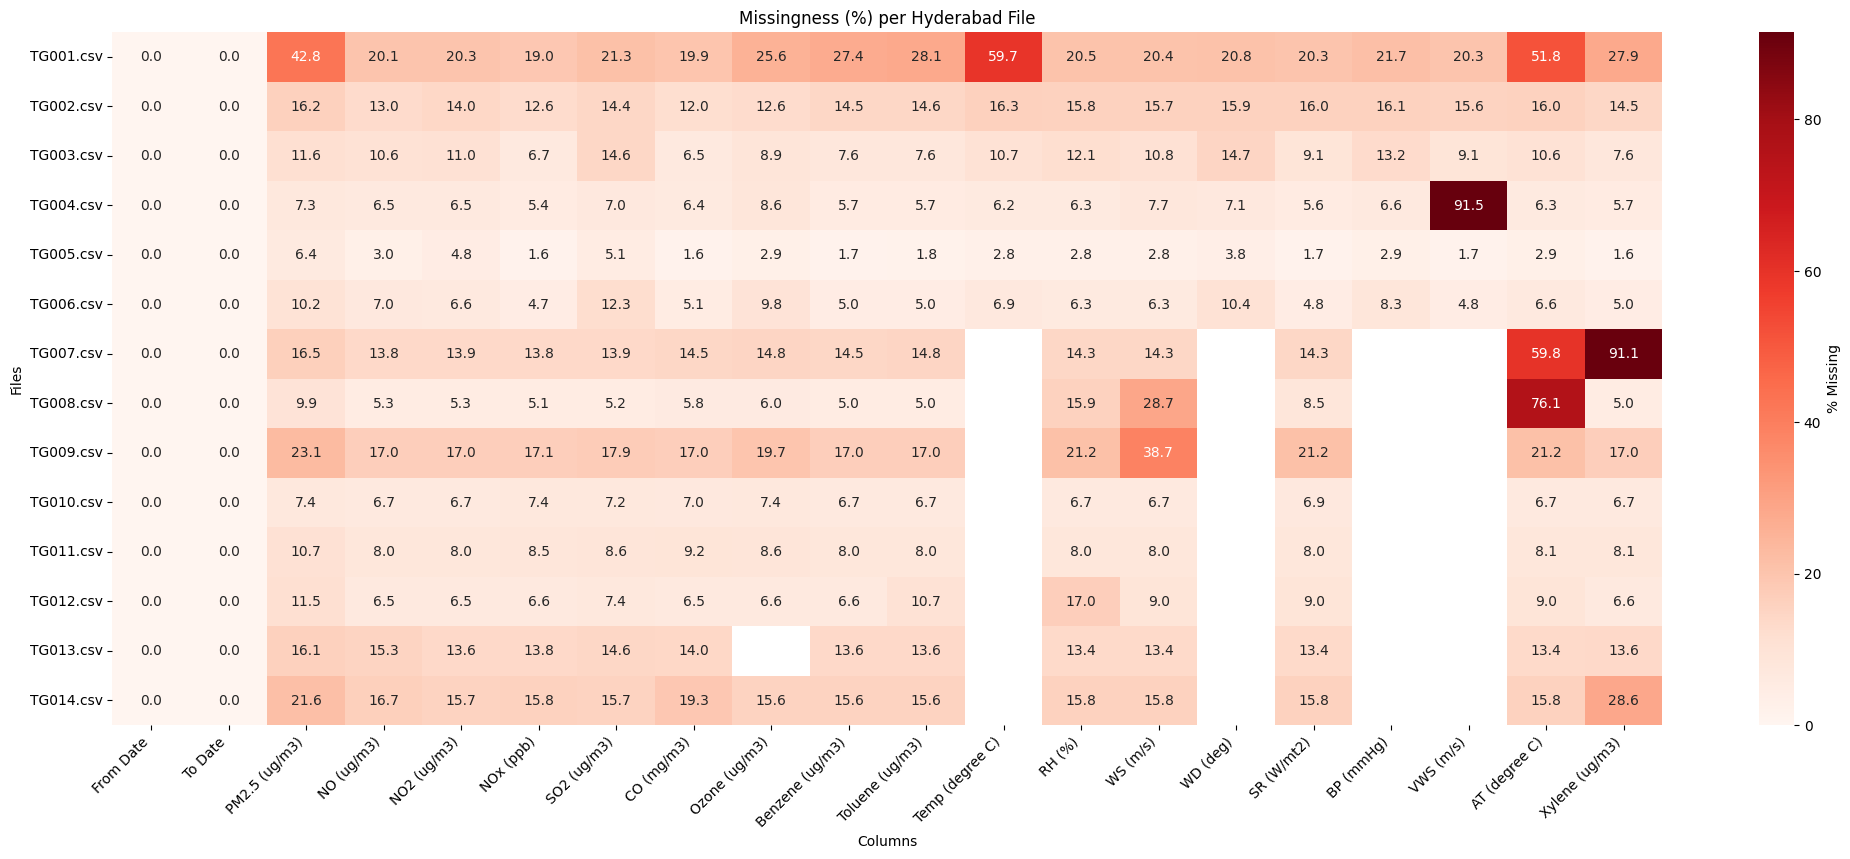

In [ ]:
plt.figure(figsize=(25,9))
sns.heatmap(missingness_df, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label':'% Missing'})
plt.title("Missingness (%) per Hyderabad File")
plt.xlabel("Columns")
plt.ylabel("Files")
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
folder = "/content/time-series-air-quality-data-of-india-2010-2023"

files_to_check = ["TG001.csv", "TG005.csv", "TG006.csv"]

for fname in files_to_check:
    file_path = os.path.join(folder, fname)
    df = pd.read_csv(file_path)
    print(f"\nColumns in {fname}:")
    print(f"Number of columns: {len(df.columns)}")
    print(df.columns.tolist())


Columns in TG001.csv:
Number of columns: 20
['From Date', 'To Date', 'PM2.5 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'AT (degree C)', 'Xylene (ug/m3)']

Columns in TG005.csv:
Number of columns: 23
['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'RF (mm)', 'AT (degree C)', 'Xylene (ug/m3)']

Columns in TG006.csv:
Number of columns: 23
['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS

In [ ]:
# TG005.csv seems like a good candidate as it has very few missing values
# and it has a wide temporal range.
# The data was collected from an agro-research institute just north-west of us.

chosen_file = "TG005.csv"
file_path = os.path.join(folder, chosen_file)
chosen_df = pd.read_csv(file_path)

columns_to_keep = [
    'From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'Temp (degree C)', 'RH (%)']

columns2017_2023 = chosen_df[columns_to_keep]

columns2017_2023.head()

from google.colab import files
df.to_csv("columns2017_2023.csv", index=False)
files.download("columns2017_2023.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Here, we took the file #5 data and reduced the date range to the first 2 months of 2023.
We also reworked the date time column to seperate into date and hour of the day columns.
We also counted the number of missing data values per day, and identified days without missing data within this time range.

Finally, we visualized the resulting dataset that was structured by hour

In [ ]:
# Create new dataset with data recorded during following period
recent_hyd_df = columns2017_2023[(columns2017_2023["From Date"] >= "2023-01-01 00:00:00") & (columns2017_2023["From Date"] < "2023-03-01 00:00:00")]

# Make sure "From Date" is datetime
recent_hyd_df["From Date"] = pd.to_datetime(recent_hyd_df["From Date"])

# Extract just the date (no time) into a helper column
recent_hyd_df["date"] = recent_hyd_df["From Date"].dt.date

# For each day, count NaNs in PM2.5 column only
nan_by_day = recent_hyd_df.groupby("date")["PM2.5 (ug/m3)"].apply(lambda x: x.isnull().sum())

print("PM2.5 NaNs per day:")
print(nan_by_day)

print("\nDays with zero PM2.5 NaNs:")
print(nan_by_day[nan_by_day == 0])

PM2.5 NaNs per day:
date
2023-01-01     0
2023-01-02     2
2023-01-03    12
2023-01-04     0
2023-01-05    10
2023-01-06     0
2023-01-07     0
2023-01-08     0
2023-01-09     0
2023-01-10     0
2023-01-11     0
2023-01-12     0
2023-01-13     0
2023-01-14     0
2023-01-15     0
2023-01-16     0
2023-01-17     0
2023-01-18     0
2023-01-19     0
2023-01-20     0
2023-01-21     1
2023-01-22     0
2023-01-23     0
2023-01-24     0
2023-01-25     0
2023-01-26     0
2023-01-27     0
2023-01-28     0
2023-01-29     0
2023-01-30     0
2023-01-31     0
2023-02-01     0
2023-02-02     0
2023-02-03     0
2023-02-04     0
2023-02-05     0
2023-02-06     0
2023-02-07     0
2023-02-08     0
2023-02-09     6
2023-02-10     0
2023-02-11     5
2023-02-12     0
2023-02-13     0
2023-02-14     0
2023-02-15     0
2023-02-16     0
2023-02-17     0
2023-02-18     0
2023-02-19     0
2023-02-20     0
2023-02-21     0
2023-02-22     0
2023-02-23     0
2023-02-24     0
2023-02-25     0
2023-02-26     0
2023-0

/tmp/ipykernel_171/801181313.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_hyd_df["From Date"] = pd.to_datetime(recent_hyd_df["From Date"])
/tmp/ipykernel_171/801181313.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_hyd_df["date"] = recent_hyd_df["From Date"].dt.date


In [ ]:
# Drop columns besides 'PM2.5 (ug/m3)', and shrink data by date
ready_hyd_df = recent_hyd_df[["From Date", "To Date", "PM2.5 (ug/m3)"]]
ready_hyd_df["date"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.date
ready_hyd_df["hour"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.hour
ready_hyd_df = ready_hyd_df.rename(columns={"From Date": "From DateTime"})

ready_hyd_df.head(50)

/tmp/ipykernel_171/1288430520.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ready_hyd_df["date"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.date
/tmp/ipykernel_171/1288430520.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ready_hyd_df["hour"] = pd.to_datetime(ready_hyd_df["From Date"]).dt.hour


,From DateTime,To Date,PM2.5 (ug/m3),date,hour
51168,2023-01-01 00:00:00,2023-01-01 01:00:00,82.25,2023-01-01,0
51169,2023-01-01 01:00:00,2023-01-01 02:00:00,75.25,2023-01-01,1
51170,2023-01-01 02:00:00,2023-01-01 03:00:00,78.75,2023-01-01,2
51171,2023-01-01 03:00:00,2023-01-01 04:00:00,80.25,2023-01-01,3
51172,2023-01-01 04:00:00,2023-01-01 05:00:00,84.75,2023-01-01,4
51173,2023-01-01 05:00:00,2023-01-01 06:00:00,77.00,2023-01-01,5
51174,2023-01-01 06:00:00,2023-01-01 07:00:00,71.33,2023-01-01,6
51175,2023-01-01 07:00:00,2023-01-01 08:00:00,65.75,2023-01-01,7
51176,2023-01-01 08:00:00,2023-01-01 09:00:00,65.75,2023-01-01,8
51177,2023-01-01 09:00:00,2023-01-01 10:00:00,65.75,2023-01-01,9


In [ ]:
# Checking quality of data
print(ready_hyd_df.describe())

# Counting N/A values
print(ready_hyd_df.isnull().sum())

                       From DateTime  PM2.5 (ug/m3)         hour
count                           1416    1380.000000  1416.000000
mean   2023-01-30 11:30:00.000000256      61.469370    11.500000
min              2023-01-01 00:00:00      16.750000     0.000000
25%              2023-01-15 17:45:00      48.187500     5.750000
50%              2023-01-30 11:30:00      64.500000    11.500000
75%              2023-02-14 05:15:00      76.750000    17.250000
max              2023-02-28 23:00:00      86.750000    23.000000
std                              NaN      17.422962     6.924632
From DateTime     0
To Date           0
PM2.5 (ug/m3)    36
date              0
hour              0
dtype: int64


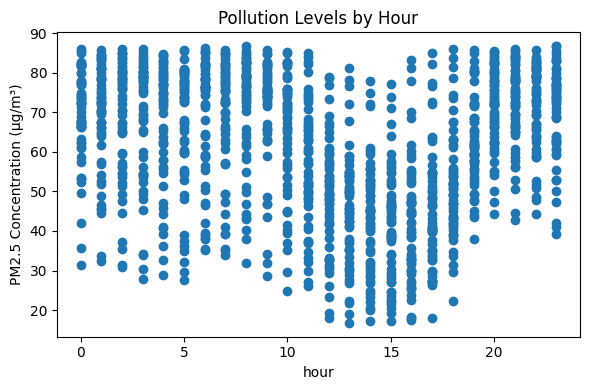

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(ready_hyd_df["hour"], ready_hyd_df["PM2.5 (ug/m3)"])

plt.xlabel("hour")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.title("Pollution Levels by Hour")

plt.tight_layout()
plt.show()

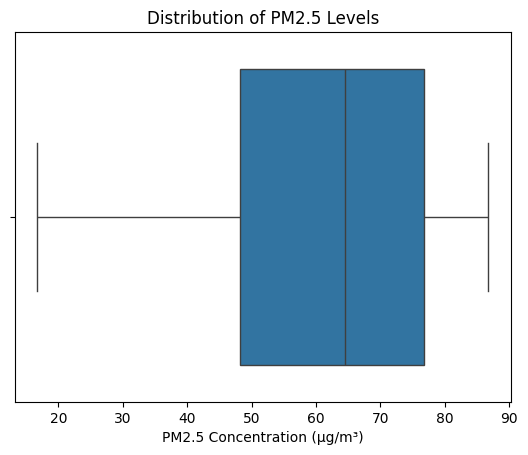

In [ ]:
#Checked for outliers with this boxplot
import seaborn as sns

sns.boxplot(x=ready_hyd_df["PM2.5 (ug/m3)"])

plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.title("Distribution of PM2.5 Levels")

plt.show()